In [1]:
from scipy.interpolate import RectBivariateSpline, interp1d
import numpy as np
from cosmopower import cosmopower_NN
import os
import matplotlib.pyplot as plt
# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

## Let's see how $\mu$ behaves on different scales

In [2]:
omega0=0.31
k = np.logspace(-3, 1, 128)

a=1.
w0=-1.
wa=0.
omegaL = (1.-omega0) * a**(-3.*(1.+w0+wa)) * np.exp(3.*(-1.+a)*wa)
omegaL0 = (1.-omega0) 
E = np.sqrt(omega0/a**3 + omegaL)

mu0=0.2


(0.001, 10)

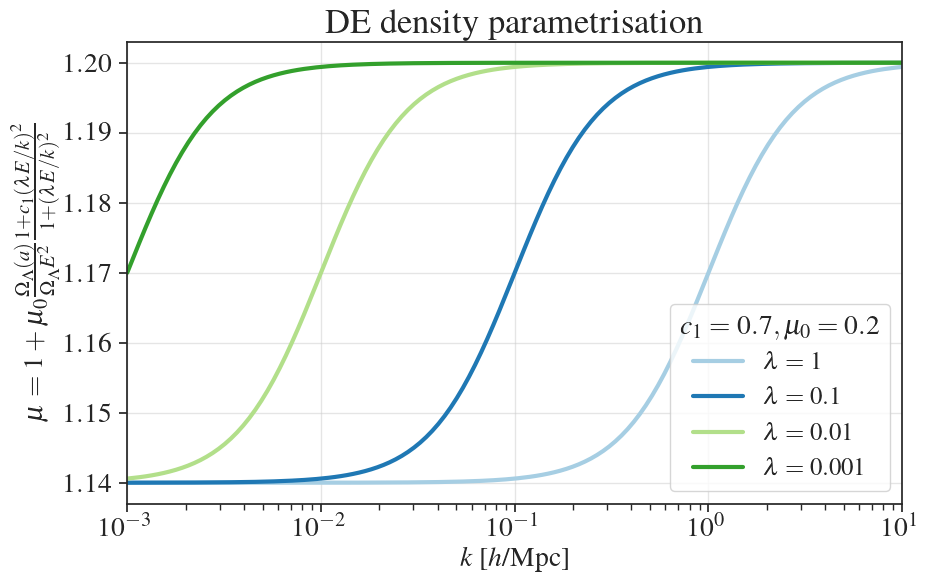

In [3]:

c1 = 0.7
mu_DE = lambda lamb: 1. + mu0*(omegaL/E**2)/omegaL0*((1+c1*(lamb*E/k)**2)/(1.+(lamb*E/k)**2))
fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', sharex=True, sharey=True)
ax.semilogx(k, mu_DE(1), label='$\\lambda=1$')
ax.semilogx(k, mu_DE(0.1), label='$\\lambda=0.1$')
ax.semilogx(k, mu_DE(0.01), label='$\\lambda=0.01$')
ax.semilogx(k, mu_DE(0.001), label='$\\lambda=0.001$')
ax.legend(title='$c_1=0.7, \\mu_0=0.2$', title_fontsize=20)
ax.set_xlabel('$k$ [$h$/Mpc]')
ax.set_ylabel('$\\mu=1+\\mu_0\\frac{\\Omega_\Lambda(a)}{\\Omega_\Lambda E^2}\\frac{1+c_1(\\lambda E/k)^2}{1+(\\lambda E/k)^2}$')
ax.set_title('DE density parametrisation')
ax.grid(alpha=0.5)
ax.set_xlim(0.001, 10)


(0.001, 10)

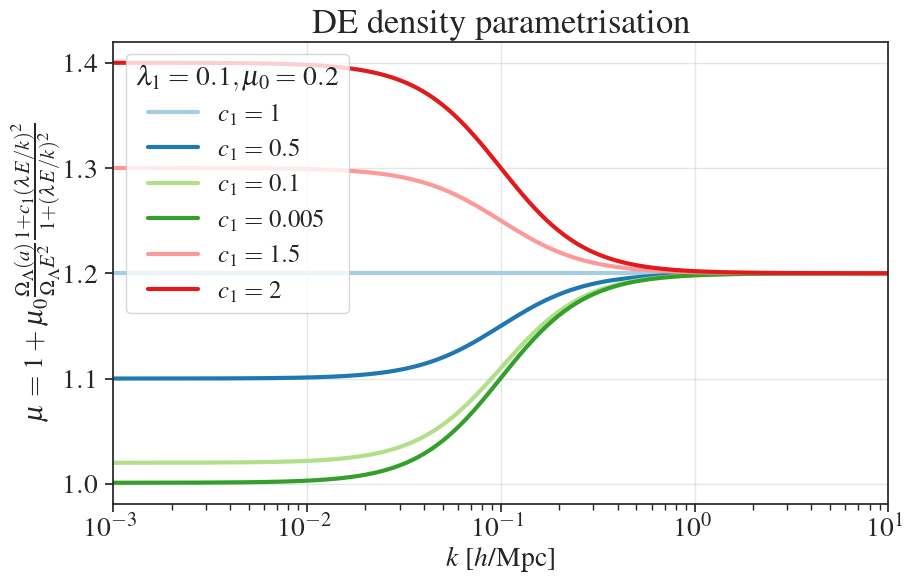

In [4]:
lamb = 0.1
mu_DE = lambda c1: 1. + mu0*(omegaL/E**2)/omegaL0*((1+c1*(lamb*E/k)**2)/(1.+(lamb*E/k)**2))

fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', sharex=True, sharey=True)
ax.semilogx(k, mu_DE(1), label='$c_1=1$')
ax.semilogx(k, mu_DE(0.5), label='$c_1=0.5$')
ax.semilogx(k, mu_DE(0.1), label='$c_1=0.1$')
ax.semilogx(k, mu_DE(0.005), label='$c_1=0.005$')
ax.semilogx(k, mu_DE(1.5), label='$c_1=1.5$')
ax.semilogx(k, mu_DE(2), label='$c_1=2$')
ax.legend(title='$\\lambda_1=0.1, \\mu_0=0.2$', title_fontsize=20)
ax.set_xlabel('$k$ [$h$/Mpc]')
ax.set_ylabel('$\\mu=1+\\mu_0\\frac{\\Omega_\Lambda(a)}{\\Omega_\Lambda E^2}\\frac{1+c_1(\\lambda E/k)^2}{1+(\\lambda E/k)^2}$')
ax.set_title('DE density parametrisation')
ax.grid(alpha=0.5)
ax.set_xlim(0.001, 10)

## Let's compare different tools on linear scales

In [5]:
import MGrowth as mg
#zz_integr never starts with 0 but with z_min
def mu_DE_func(a, k, omega0, mu0, c1, lamb, w0=-1, wa=0.):
    omegaL = (1.-omega0) * a**(-3.*(1.+w0+wa)) * np.exp(3.*(-1.+a)*wa)
    omegaL0 = (1.-omega0) 
    E = np.sqrt(omega0/a**3 + omegaL)
    mu_DE = 1. + mu0*(omegaL/E**2)/omegaL0*((1+c1*(lamb*E/k)**2)/(1.+(lamb*E/k)**2))
    return mu_DE

def get_boost_mgrowth(params_dic, zz_integr):
    aa_integr =  np.array(1./(1.+zz_integr[::-1]))
    background ={
        'Omega_m': params_dic['Omega_m'],
        'h' : params_dic['h'],
        'w0': -1.,
        'wa': 0.,
        'a_arr': aa_integr #np.hstack((aa_integr, 1.))
        }
    cosmo = mg.mu_a(background) 
    aa_interp = np.linspace(1e-3, 1, 100)
    mu_de_k = np.array([mu_DE_func(aa_interp,  k_i, params_dic['Omega_m'], params_dic['mu0'], params_dic['c1'], params_dic['lam']) for k_i in k])
    mu_interpolator_k = np.array([interp1d(aa_interp, mu_de_k_i, bounds_error=False,
                kind='cubic',
                fill_value=(mu_de_k_i[0], mu_de_k_i[-1])) for mu_de_k_i in mu_de_k]) 
    d_f_i =  [cosmo.growth_parameters(mu_interp=mu_interpolator_k_i) for mu_interpolator_k_i in mu_interpolator_k]
    da = np.array([d_i for d_i, _ in d_f_i])
    # return array of k and z
    dz = da[:, ::-1] 


    


    cosmo_lcdm = mg.LCDM(background)
    da, _ = cosmo_lcdm.growth_parameters()  
    dz_lcdm = da[::-1] 

    return dz/dz_lcdm

In [6]:

cp_nl_model = cosmopower_NN(restore=True, 
                        restore_filename='../emulators/mu_sigma/mu_z_k/react_boost_mu_z_k_q123', 
                        )
kh_nl_boost = cp_nl_model.modes # 0.01..5. h/Mpc 

def get_boost_react(params_dic, zz_integr):
    ns   = params_dic['ns']
    a_s   = params_dic['As']
    h    = params_dic['h']
    omega_b = params_dic['Omega_b']
    omega_m = params_dic['Omega_m']
    omega_nu  = params_dic['Omega_nu']
    w0    = params_dic['w0']
    wa    = params_dic['wa']
    mu0    = params_dic['mu0']
    c1    = params_dic['c1']
    lam    = params_dic['lam']
    q1    = params_dic['q1']
    q2    = params_dic['q2']
    q3    = params_dic['q3']
    nz_pk = len(zz_integr)
    params_react = {
            'ns'            :  np.full(nz_pk, ns),
            'As'            :  np.full(nz_pk, a_s),
            'H0'            :  np.full(nz_pk, h*100),
            'Omega_b'       :  np.full(nz_pk, omega_b),
            'Omega_m'       :  np.full(nz_pk, omega_m),
            'Omega_nu'      :  np.full(nz_pk, omega_nu),
            'w0'        :  np.full(nz_pk, w0),
            'wa'        :  np.full(nz_pk, wa),
            'mu0'        :  np.full(nz_pk, mu0),
            'c1'        :  np.full(nz_pk, c1),
            'lam'        :  np.full(nz_pk, lam),
            'q1'            :  np.full(nz_pk, q1),
            'q2'            :  np.full(nz_pk, q2),
            'q3'            :  np.full(nz_pk, q3),
            'z'             :  zz_integr
        }

    mg_boost_lcdm = cp_nl_model.predictions_np(params_react) 
    return mg_boost_lcdm

2026-04-01 10:24:53.557347: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-01 10:24:53.557386: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-01 10:24:53.557397: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-04-01 10:24:53.557650: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-01 10:24:53.558110: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
cp_lin_model = cosmopower_NN(restore=True, 
                        restore_filename='../emulators/mu_sigma/mu_z/mgcamb_log10_total_matter_linear', 
                        )
kh_lin = cp_lin_model.modes # 0.01..5. h/Mpc 

def get_boost_lin(params_dic, zz_integr):
    ns   = params_dic['ns']
    a_s   = params_dic['As']
    h    = params_dic['h']
    omega_b = params_dic['Omega_b']
    omega_m = params_dic['Omega_m']
    omega_nu  = params_dic['Omega_nu']
    mu0    = params_dic['mu0']
    c1    = params_dic['c1']
    q1    = params_dic['q1']
    nz_pk = len(zz_integr)
    params_react = {
            'ns'            :  np.full(nz_pk, ns),
            'As'            :  np.full(nz_pk, a_s),
            'H0'            :  np.full(nz_pk, h*100),
            'Omega_b'       :  np.full(nz_pk, omega_b),
            'Omega_m'       :  np.full(nz_pk, omega_m),
            'Omega_nu'      :  np.full(nz_pk, omega_nu),
            'mu0'        :  np.full(nz_pk, mu0),
            'sigma0'        :  np.full(nz_pk, 0.),
            'q1'            :  np.full(nz_pk, q1),
            'z'             :  zz_integr
        }
    mg_lin = cp_lin_model.ten_to_predictions_np(params_react) 
    params_react['mu0'] = np.full(nz_pk, 0.)
    gr_lin = cp_lin_model.ten_to_predictions_np(params_react) 
    mg_boost_lin = mg_lin/gr_lin
    return mg_boost_lin

In [8]:
params_dic = {
    'Omega_m': 0.31,
    'Omega_b': 0.049,
    'Omega_nu': 0.0,
    'w0': -1.,
    'wa': 0.,
    'ns': 0.97,
    'As': 2.1e-9,
    'h': 0.67,

    'q1': 2.,
    'q2': 2.,
    'q3': 2.,

    'mu0': 0.7,
    'c1': 1., 
    'lam': 0. 
}
zz_integr = np.linspace(0.0, 1., 3)
mg_boosts = get_boost_mgrowth(params_dic, zz_integr)


react_boosts = get_boost_react(params_dic, zz_integr)

lin_boosts = get_boost_lin(params_dic, zz_integr)

(0.99, 1.4)

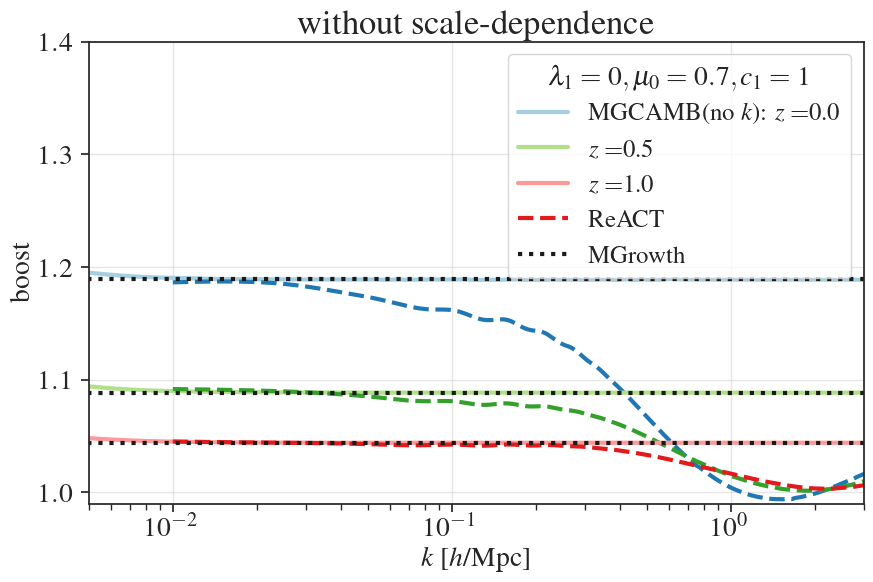

In [9]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', sharex=True, sharey=True)
for i in range(len(zz_integr)):
    ax.semilogx(kh_lin, lin_boosts[i, :], linestyle='-', label='MGCAMB(no $k$): $z=$' + str(zz_integr[i]) if i == 0 else '$z=$' + str(zz_integr[i]))
    ax.semilogx(kh_nl_boost, react_boosts[i, :], linestyle='--', label='ReACT' if i == len(zz_integr)-1 else None)
    ax.semilogx(k, mg_boosts[:, i]**2, color='k', linestyle=':', label='MGrowth' if i == len(zz_integr)-1 else None)
ax.legend(title='$\\lambda_1=0, \\mu_0=0.7, c_1=1$', title_fontsize=20)
ax.set_xlabel('$k$ [$h$/Mpc]')
ax.set_ylabel('boost')
ax.set_title('without scale-dependence')
ax.grid(alpha=0.5)
ax.set_xlim(0.005, 3.)
ax.set_ylim(0.99, 1.4)

In [10]:
params_dic = {
    'Omega_m': 0.31,
    'Omega_b': 0.049,
    'Omega_nu': 0.0,
    'w0': -1.,
    'wa': 0.,
    'ns': 0.97,
    'As': 2.1e-9,
    'h': 0.67,

    'q1': 2.,
    'q2': 2.,
    'q3': 2.,

    'mu0': 0.7,
    'c1': 0.7, 
    'lam': 0.1 
}
zz_integr = np.linspace(0.0, 1., 3)
mg_boosts = get_boost_mgrowth(params_dic, zz_integr)
react_boosts = get_boost_react(params_dic, zz_integr)
lin_boosts = get_boost_lin(params_dic, zz_integr)

(0.99, 1.4)

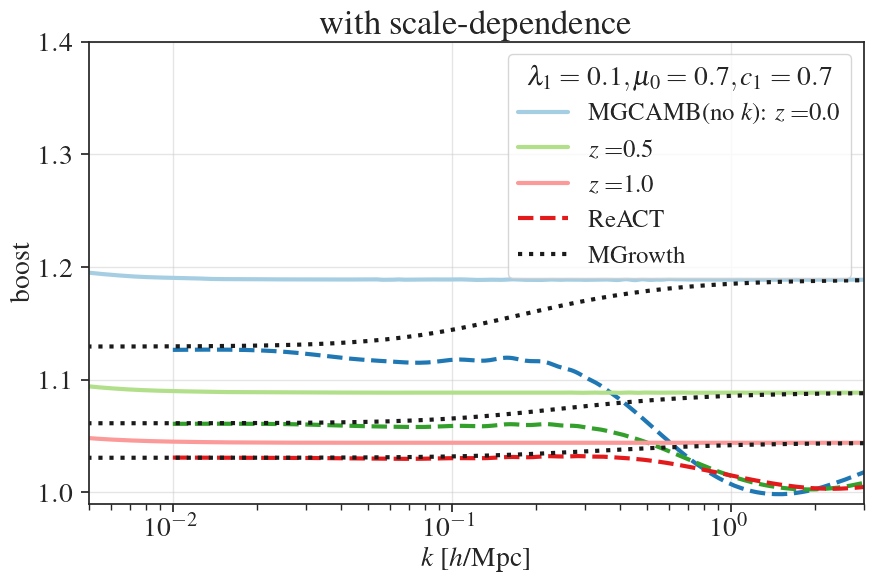

In [11]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', sharex=True, sharey=True)
for i in range(len(zz_integr)):
    ax.semilogx(kh_lin, lin_boosts[i, :], linestyle='-', label='MGCAMB(no $k$): $z=$' + str(zz_integr[i]) if i == 0 else '$z=$' + str(zz_integr[i]))
    ax.semilogx(kh_nl_boost, react_boosts[i, :], linestyle='--', label='ReACT' if i == len(zz_integr)-1 else None)
    ax.semilogx(k, mg_boosts[:, i]**2, color='k', linestyle=':', label='MGrowth' if i == len(zz_integr)-1 else None)
ax.legend(title='$\\lambda_1=0.1, \\mu_0=0.7, c_1=0.7$', title_fontsize=20)
ax.set_xlabel('$k$ [$h$/Mpc]')
ax.set_ylabel('boost')
ax.set_title('with scale-dependence')
ax.grid(alpha=0.5)
ax.set_xlim(0.005, 3.)
ax.set_ylim(0.99, 1.4)

## Let's compare our implementation in MGL

In [12]:
import os
# switch to the main directory
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
import MGLensing
import numpy as np

Bacco not installed!
euclidlib not installed! Euclid TR1 setup will not be available!
/Users/s2265800/Desktop/GitHub/MGlensing/MGLensing


In [13]:
MGL = MGLensing.MGL("ini_files/config_files/config_hmcode.yaml")
zz = MGL.Survey.zz_integr
nbin = MGL.Survey.nbin_s


l_wl_max, l_gc_max = MGL.Survey.ells_wl_max, MGL.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL.Survey.l_wl, MGL.Survey.l_gc, MGL.Survey.l_xc

Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  0
initialising hmcode
Zennaro 2024 cross-sqrt-bar boost is applied with self.flag_cross_sqrt_bar_boost:  False
################################
checking parameters for data....
all good with the data dictionary
################################
start c

In [40]:
params = {
    'Omega_m' :  0.315,
    'Omega_c' :  0.315-0.05,
    'Omega_cb' :  0.315,
    'Omega_nu':  0.,
    'As'      :  np.exp(3.07)*1.e-10,
    'Omega_b' :  0.049,
    'ns'      :  0.9649,
    'h'       :  0.67,
    'Mnu'     :  0.0,
    'w0'      :  -1.0,
    'wa'      :  0.0,
    'a1_IA': 0.16,
    'eta1_IA': 1.66,
    'beta_IA': 0.,
    'mu0': 1.5,
    'sigma0': 0.,
    'c1': 1.,
    'lam': 0.,
    'q1': 0.8,
    'q2': 0.,
    'q3': 0.,

}

b0 = 0.68
bias1_arr = np.array([b0*(1.+z_bin_center_i) for z_bin_center_i in MGL.Survey.z_bin_center_l ])
for bin_i in range(nbin):
    params[f'b1_{bin_i+1}']=bias1_arr[bin_i]

In [41]:
# first call MGL
NL_MODEL_HMCODE = 0
NL_MODEL_BACCO = 1
NL_MODEL_NDGP = 2
NL_MODEL_GAMMAZ = 3
NL_MODEL_MUSIGMA = 4
NL_MODEL_DS = 5
NL_MODEL_FOFR = 6
NL_MODEL_FOFR_EMANTIS = 7
NL_MODEL_NDGP_EMU = 8
NL_MODEL_MUKZ = 9
NL_MODEL_MUSIGMA_Q123 = 10
NL_MODEL_MUSPLINE = 11

models_muz = {
    'nonlin': {'nl_model': NL_MODEL_MUSIGMA, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'lin': {'nl_model': NL_MODEL_MUSIGMA, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'pseudo': {'nl_model': NL_MODEL_MUSIGMA, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.}
    }

models_muzq123 = {
    'nonlin': {'nl_model': NL_MODEL_MUSIGMA_Q123, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'lin': {'nl_model': NL_MODEL_MUSIGMA_Q123, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'pseudo': {'nl_model': NL_MODEL_MUSIGMA_Q123, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.}
    }

models_muzk = {
    'nonlin': {'nl_model': NL_MODEL_MUKZ, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'lin': {'nl_model': NL_MODEL_MUKZ, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'pseudo': {'nl_model': NL_MODEL_MUKZ, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.}
    }

In [42]:
power_spectra_muz = {}
for model_opt in models_muz:
    try:
        k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params, models_muz[model_opt])
        print(f"Model: {model_opt}, k_ell shape: {k_ell.shape}, pmm shape: {pmm.shape}, pgm shape: {pgm.shape}, pgg shape: {pgg.shape}")
        power_spectra_muz[model_opt] = {
            'k': k_ell,
            'pmm': pmm,
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  4
initialising mu-Sigma
Model: nonlin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)
model["nl_model"] =  4
initialising mu-Sigma
Model: lin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)
model["nl_model"] =  4
initialising mu-Sigma
Model: pseudo, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)


In [43]:
power_spectra_muzk = {}
for model_opt in models_muzk:
    try:
        k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params, models_muzk[model_opt])
        print(f"Model: {model_opt}, k_ell shape: {k_ell.shape}, pmm shape: {pmm.shape}, pgm shape: {pgm.shape}, pgg shape: {pgg.shape}")
        power_spectra_muzk[model_opt] = {
            'k': k_ell,
            'pmm': pmm,
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  9
initialising Scale-dependent mu-Sigma Parametrisation
initialising ReACT scale-dep mu
initialising hmcode
Model: nonlin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)
model["nl_model"] =  9
initialising Scale-dependent mu-Sigma Parametrisation
initialising ReACT scale-dep mu
initialising hmcode
Model: lin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)
model["nl_model"] =  9
initialising Scale-dependent mu-Sigma Parametrisation
initialising ReACT scale-dep mu
initialising hmcode
Model: pseudo, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)


In [44]:
power_spectra_muzq123 = {}
for model_opt in models_muzq123:
    try:
        k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params, models_muzq123[model_opt])
        print(f"Model: {model_opt}, k_ell shape: {k_ell.shape}, pmm shape: {pmm.shape}, pgm shape: {pgm.shape}, pgg shape: {pgg.shape}")
        power_spectra_muzq123[model_opt] = {
            'k': k_ell,
            'pmm': pmm,
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  10
initialising Scale-independent mu-Sigma Parametrisation
initialising ReACT scale-indep mu
Model: nonlin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)
model["nl_model"] =  10
initialising Scale-independent mu-Sigma Parametrisation
initialising ReACT scale-indep mu
Model: lin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)
model["nl_model"] =  10
initialising Scale-independent mu-Sigma Parametrisation
initialising ReACT scale-indep mu
Model: pseudo, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)


In [32]:
_, rcom = MGL.get_expansion_and_rcom(params)
# pick 3 redshifts
z_int_pick = [20, 50, 80] #goes from 0 to 255
def k2ell(x, ind=z_int_pick[0]):
    return x*rcom[ind]-0.5
def ell2k(x, ind=z_int_pick[0]):
    return (x+0.5)/rcom[ind]
def k2ell1(x, ind=z_int_pick[1]):
    return x*rcom[ind]-0.5
def ell2k1(x, ind=z_int_pick[1]):
    return (x+0.5)/rcom[ind]
def k2ell2(x, ind=z_int_pick[2]):
    return x*rcom[ind]-0.5
def ell2k2(x, ind=z_int_pick[2]):
    return (x+0.5)/rcom[ind]
f_arr = [k2ell, k2ell1, k2ell2]
f_inv_arr = [ell2k, ell2k1, ell2k2]
# pick the bins
bin_i=1
bin_j=1

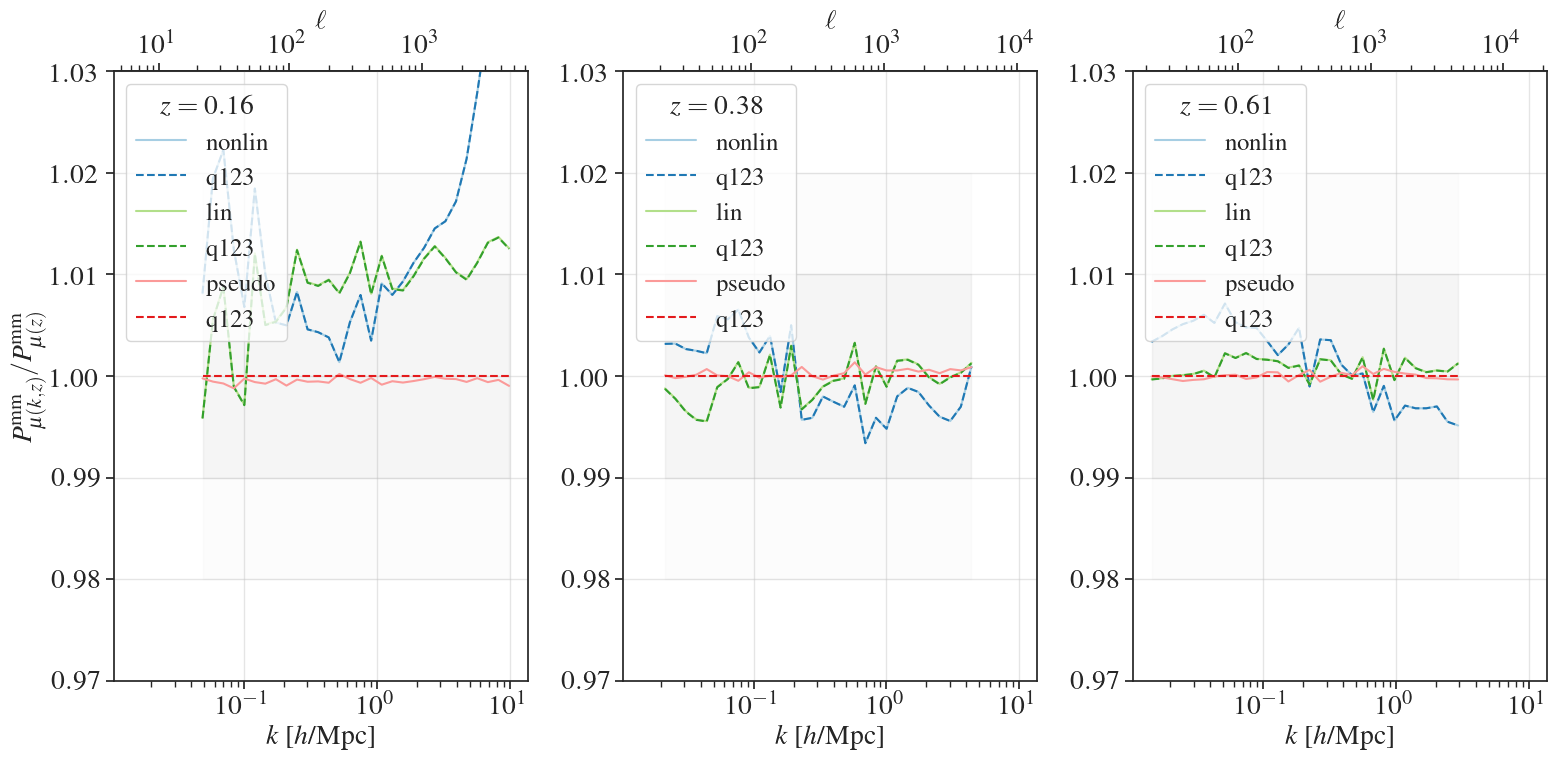

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8), facecolor='w',  sharex=True)
for i in range(3):
    k_ell = power_spectra_muzk['nonlin']['k']
    pmm_zk = power_spectra_muzk['nonlin']['pmm']
    pmm_z = power_spectra_muz['nonlin']['pmm']
    pmm_zq123 = power_spectra_muzq123['nonlin']['pmm']
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_zk[:, z_int_pick[i]]/pmm_z[:, z_int_pick[i]], linewidth=1.5, label='nonlin')#, color = colors[num])
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_zq123[:, z_int_pick[i]]/pmm_z[:, z_int_pick[i]], linewidth=1.5, label='q123', linestyle='--')#, color = colors[num])
    pmm_zk_lin = power_spectra_muzk['lin']['pmm']
    pmm_z_lin = power_spectra_muz['lin']['pmm']
    pmm_zq123_lin = power_spectra_muzq123['lin']['pmm']
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_zk_lin[:, z_int_pick[i]]/pmm_z_lin[:, z_int_pick[i]], linewidth=1.5, label='lin')#, color = colors[num])
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_zq123_lin[:, z_int_pick[i]]/pmm_z_lin[:, z_int_pick[i]], linewidth=1.5, label='q123', linestyle='--')#, color = colors[num])

    pmm_zk = power_spectra_muzk['pseudo']['pmm']
    pmm_z = power_spectra_muz['pseudo']['pmm']
    pmm_zq123_pseudo = power_spectra_muzq123['pseudo']['pmm']
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_zk[:, z_int_pick[i]]/pmm_z[:, z_int_pick[i]], linewidth=1.5, label='pseudo')#, color = colors[num])
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_zq123_pseudo[:, z_int_pick[i]]/pmm_z[:, z_int_pick[i]], linewidth=1.5, label='q123', linestyle='--')#, color = colors[num])
  

    
    ax[i].fill_between(k_ell[:, z_int_pick[i]], np.ones(len(k_ell[:, z_int_pick[i]]))*0.99, np.ones(len(k_ell[:, z_int_pick[i]]))*1.01, color='tab:grey', alpha=0.05)
    ax[i].fill_between(k_ell[:, z_int_pick[i]], np.ones(len(k_ell[:, z_int_pick[i]]))*0.98, np.ones(len(k_ell[:, z_int_pick[i]]))*1.02, color='tab:grey', alpha=0.02)

    ax[i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='upper left', frameon=True, title_fontsize=20)
    ax[i].set_xlabel("$k$ [$h$/Mpc]")
    secax = ax[i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')
    ax[i].grid(alpha=0.5) 
    ax[i].set_ylim(0.97, 1.03)   
    #ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0].set_ylabel("$P^{\\rm mm}_{\\mu(k, z)}/P^{\\rm mm}_{\\mu(z)}$")
plt.tight_layout()

## Let's test-out the $\mu$-spline implementation with 3 bins (4 $\mu$ values)

In [34]:
# the difference to mu0 from above is that it's the total mu in each bin, not mu=1+mu_i
params['mu0'] = 1.12345679
params['mu1'] = 1.11522701
params['mu2'] = 1.05933458
params['mu3'] = 1.04570046

In [35]:
models_muspline = {
    'lin': {'nl_model': NL_MODEL_MUSPLINE, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
    'pseudo': {'nl_model': NL_MODEL_MUSPLINE, 'option': 'pseudo', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.}
    }

In [36]:
power_spectra_muspline = {}
for model_opt in models_muspline:
    try:
        k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params, models_muspline[model_opt])
        print(f"Model: {model_opt}, k_ell shape: {k_ell.shape}, pmm shape: {pmm.shape}, pgm shape: {pgm.shape}, pgg shape: {pgg.shape}")
        power_spectra_muspline[model_opt] = {
            'k': k_ell,
            'pmm': pmm,
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  11
initialising scale-indep mu
Model: lin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)
model["nl_model"] =  11
initialising scale-indep mu
Model: pseudo, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)


In [37]:
models_gr =     {'nonlin': {'nl_model': NL_MODEL_HMCODE, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.},
                'lin': {'nl_model': NL_MODEL_HMCODE, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.}
                }

power_spectra_gr = {}
for model_opt in models_gr:
    try:
        k_ell, pmm, pgm, pgg = MGL.get_power_spectra(params, models_gr[model_opt])
        print(f"Model: {model_opt}, k_ell shape: {k_ell.shape}, pmm shape: {pmm.shape}, pgm shape: {pgm.shape}, pgg shape: {pgg.shape}")
        power_spectra_gr[model_opt] = {
            'k': k_ell,
            'pmm': pmm,
        }
    except ValueError as e:
        print(f"Error with model {model_opt}: {e}")

model["nl_model"] =  0
initialising hmcode
Model: nonlin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)
model["nl_model"] =  0
initialising hmcode
Model: lin, k_ell shape: (30, 400), pmm shape: (30, 400), pgm shape: (30, 400, 5), pgg shape: (30, 400, 5, 5)


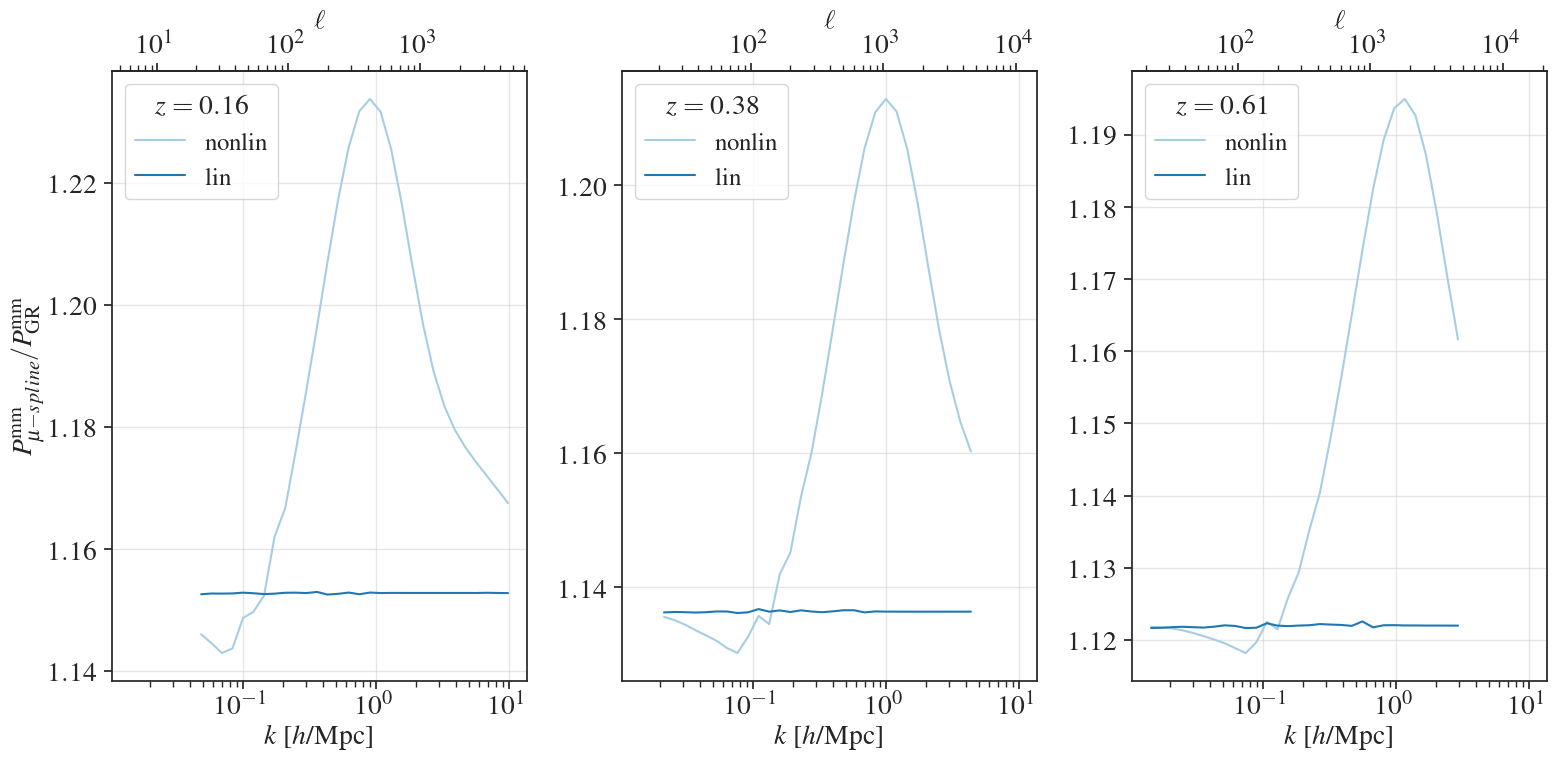

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8), facecolor='w',  sharex=True)
for i in range(3):
    k_ell = power_spectra_gr['nonlin']['k']
    pmm_gr = power_spectra_gr['nonlin']['pmm']
    pmm_mu = power_spectra_muspline['pseudo']['pmm']
    
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_mu[:, z_int_pick[i]]/pmm_gr[:, z_int_pick[i]], linewidth=1.5, label='nonlin')#, color = colors[num])
    
    pmm_gr_lin = power_spectra_gr['lin']['pmm']
    pmm_mu_lin = power_spectra_muspline['lin']['pmm']
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_mu_lin[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, label='lin')#, color = colors[num])

    
    
    ax[i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='upper left', frameon=True, title_fontsize=20)
    ax[i].set_xlabel("$k$ [$h$/Mpc]")
    secax = ax[i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')
    ax[i].grid(alpha=0.5) 
    #ax[i].set_ylim(0.97, 1.03)   
    #ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0].set_ylabel("$P^{\\rm mm}_{\\mu-spline}/P^{\\rm mm}_{\\rm GR}$")
plt.tight_layout()

The dip around $k=0.1\,h/$Mpc is an expected feature from HMCode2020.

Let's check the ratios wrt to GR for our implementations above.

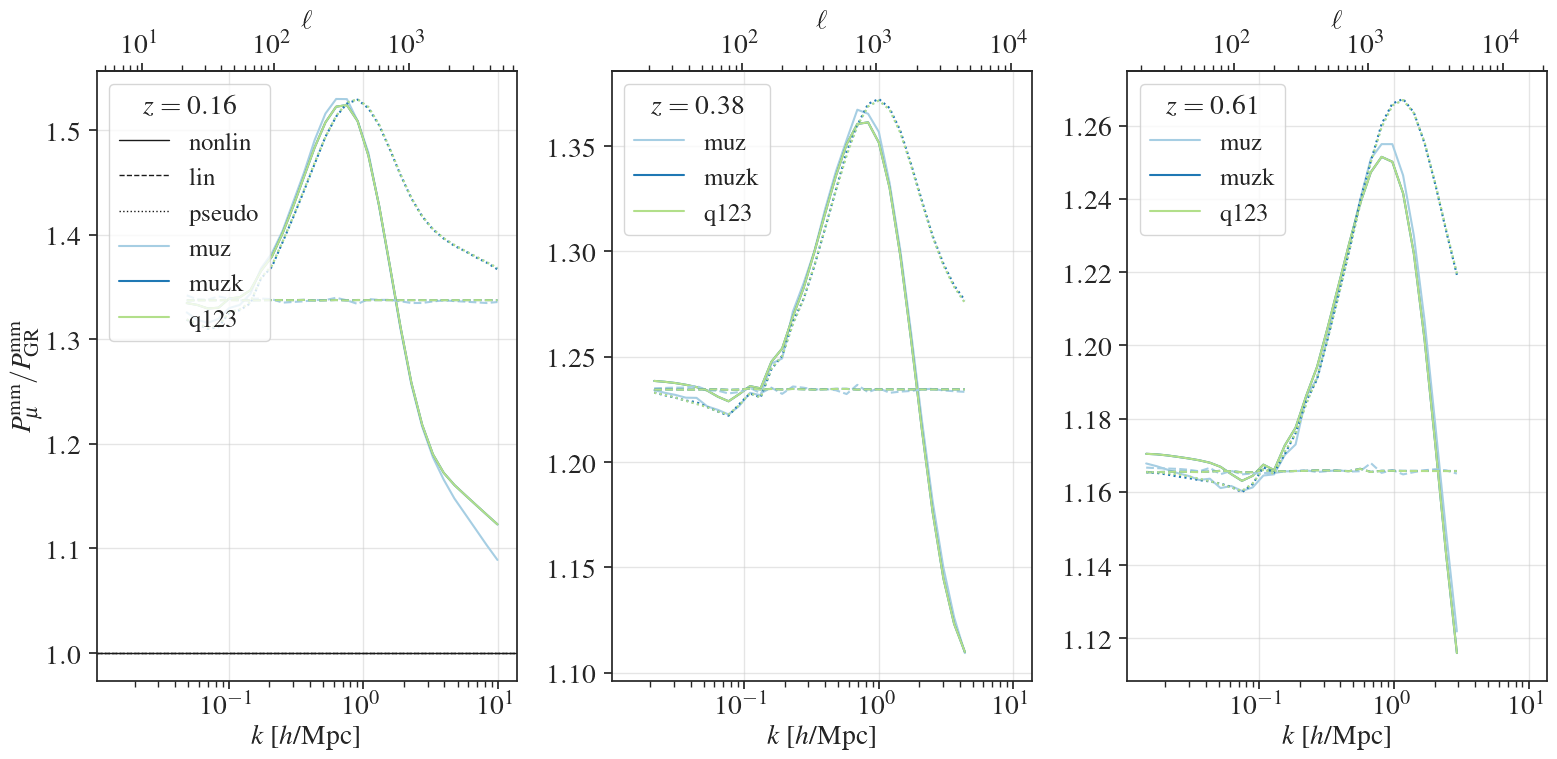

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8), facecolor='w',  sharex=True)
ax[0].axhline(y=1.0, color='k', linestyle='-', linewidth=1, label='nonlin')
ax[0].axhline(y=1.0, color='k', linestyle='--', linewidth=1, label='lin')
ax[0].axhline(y=1.0, color='k', linestyle=':', linewidth=1, label='pseudo')
for i in range(3):
    k_ell = power_spectra_gr['nonlin']['k']
    pmm_gr = power_spectra_gr['nonlin']['pmm']
    pmm_muq123 = power_spectra_muzq123['nonlin']['pmm']
    pmm_muz = power_spectra_muz['nonlin']['pmm']
    pmm_muzk = power_spectra_muzk['nonlin']['pmm']

    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_muz[:, z_int_pick[i]]/pmm_gr[:, z_int_pick[i]], linewidth=1.5, label='muz', linestyle='-', color = 'C0')
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_muzk[:, z_int_pick[i]]/pmm_gr[:, z_int_pick[i]], linewidth=1.5, label='muzk', linestyle='-', color = 'C1')
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_muq123[:, z_int_pick[i]]/pmm_gr[:, z_int_pick[i]], linewidth=1.5, label='q123', linestyle='-', color = 'C2')
    
    pmm_gr_lin = power_spectra_gr['lin']['pmm']
    pmm_muq123_lin = power_spectra_muzq123['lin']['pmm']
    pmm_muz_lin = power_spectra_muz['lin']['pmm']
    pmm_muzk_lin = power_spectra_muzk['lin']['pmm']

    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_muz_lin[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, linestyle='--', color = 'C0')
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_muzk_lin[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, linestyle='--', color = 'C1')
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_muq123_lin[:, z_int_pick[i]]/pmm_gr_lin[:, z_int_pick[i]], linewidth=1.5, linestyle='--', color = 'C2')
    
    pmm_gr = power_spectra_gr['nonlin']['pmm']
    pmm_muq123 = power_spectra_muzq123['pseudo']['pmm']
    pmm_muz= power_spectra_muz['pseudo']['pmm']
    pmm_muzk = power_spectra_muzk['pseudo']['pmm']

    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_muz[:, z_int_pick[i]]/pmm_gr[:, z_int_pick[i]], linewidth=1.5, linestyle=':', color = 'C0')
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_muzk[:, z_int_pick[i]]/pmm_gr[:, z_int_pick[i]], linewidth=1.5, linestyle=':', color = 'C1')
    ax[i].semilogx(k_ell[:, z_int_pick[i]], pmm_muq123[:, z_int_pick[i]]/pmm_gr[:, z_int_pick[i]], linewidth=1.5, linestyle=':', color = 'C2')
    
    
    ax[i].legend(title=f'$z={zz[z_int_pick[i]]:.2f}$', loc='upper left', frameon=True, title_fontsize=20)
    ax[i].set_xlabel("$k$ [$h$/Mpc]")
    secax = ax[i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')
    ax[i].grid(alpha=0.5) 
    #ax[i].set_ylim(0.97, 1.03)   
    #ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0].set_ylabel("$P^{\\rm mm}_{\\mu}/P^{\\rm mm}_{\\rm GR}$")
plt.tight_layout()